<a href="https://colab.research.google.com/github/beef-broccoli/ColabDesign/blob/main/af/examples/af_cyc_design_dev_custom_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#af_cyc_design

**Cyclic peptide structure prediction and design using AlphaFold**

Stephen Rettie, Katelyn Campbell, Asim Bera, Alex Kang, Simon Kozlov, Joshmyn De La Cruz, Victor Adebomi, Guangfeng Zhou, Frank DiMaio, Sergey Ovchinnikov, Gaurav Bhardwaj

doi: https://doi.org/10.1101/2023.02.25.529956


In [1]:
#@title setup (~2 minutes)
%%time
import os
if not os.path.isdir("params"):
  # get code
  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git@v1.1.1")
  # for debugging
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")
  # download params
  os.system("mkdir params")
  os.system("apt-get install aria2 -qq")
  os.system("aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar")
  os.system("tar -xf alphafold_params_2022-12-06.tar -C params")

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
from colabdesign import mk_afdesign_model, clear_mem
from IPython.display import HTML
from google.colab import files
import numpy as np

import jax
import jax.numpy as jnp
from colabdesign.af.alphafold.common import residue_constants

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.system(f"wget -qnc https://files.rcsb.org/view/{pdb_code}.pdb")
    return f"{pdb_code}.pdb"
  else:
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v3.pdb")
    return f"AF-{pdb_code}-F1-model_v3.pdb"

def add_cyclic_offset(self, offset_type=2):
  '''add cyclic offset to connect N and C term'''
  def cyclic_offset(L):
    i = np.arange(L)
    ij = np.stack([i,i+L],-1)
    offset = i[:,None] - i[None,:]
    c_offset = np.abs(ij[:,None,:,None] - ij[None,:,None,:]).min((2,3))
    if offset_type == 1:
      c_offset = c_offset
    elif offset_type >= 2:
      a = c_offset < np.abs(offset)
      c_offset[a] = -c_offset[a]
    if offset_type == 3:
      idx = np.abs(c_offset) > 2
      c_offset[idx] = (32 * c_offset[idx] )/  abs(c_offset[idx])
    return c_offset * np.sign(offset)
  idx = self._inputs["residue_index"]
  offset = np.array(idx[:,None] - idx[None,:])

  if self.protocol == "binder":
    c_offset = cyclic_offset(self._binder_len)
    offset[self._target_len:,self._target_len:] = c_offset

  if self.protocol in ["fixbb","partial","hallucination"]:
    Ln = 0
    for L in self._lengths:
      offset[Ln:Ln+L,Ln:Ln+L] = cyclic_offset(L)
      Ln += L
  self._inputs["offset"] = offset

def add_rg_loss(self, weight=0.1):
  '''add radius of gyration loss'''
  def loss_fn(inputs, outputs):
    xyz = outputs["structure_module"]
    ca = xyz["final_atom_positions"][:,residue_constants.atom_order["CA"]]
    rg = jnp.sqrt(jnp.square(ca - ca.mean(0)).sum(-1).mean() + 1e-8)
    rg_th = 2.38 * ca.shape[0] ** 0.365
    rg = jax.nn.elu(rg - rg_th)
    return {"rg":rg}
  self._callbacks["model"]["loss"].append(loss_fn)
  self.opt["weights"]["rg"] = weight

CPU times: user 1.56 s, sys: 218 ms, total: 1.78 s
Wall time: 1min 45s


# fixed backbone design (fixbb) (~2 minutes)
For a given protein backbone, generate/design a new sequence that AlphaFold thinks folds into that conformation.

In [2]:
clear_mem()
af_model = mk_afdesign_model(protocol="fixbb")
af_model.prep_inputs(pdb_filename=get_pdb("7m28"), chain="A")
add_cyclic_offset(af_model, offset_type=2)

print("length",  af_model._len)
print("weights", af_model.opt["weights"])

length 7
weights {'con': 0.0, 'dgram_cce': 1.0, 'exp_res': 0.0, 'fape': 0.0, 'helix': 0.0, 'pae': 0.0, 'plddt': 0.0, 'rmsd': 0.0, 'seq_ent': 0.0}


In [16]:
import jax
import jax.numpy as jnp
from colabdesign import mk_afdesign_model, clear_mem
from colabdesign.af.alphafold.common import residue_constants

# Dummy JAX NN: per-residue feature -> scalar score
def nn_forward(nn_params, x):
    h = jnp.tanh(x @ nn_params["w1"] + nn_params["b1"])
    y = h @ nn_params["w2"] + nn_params["b2"]
    return y

def nn_loss(inputs, outputs):
    # AlphaFold final atom positions are available in outputs
    pos = outputs["structure_module"]["final_atom_positions"]
    ca = pos[:, residue_constants.atom_order["CA"]]   # (L, 3)

    # Simple differentiable features per residue
    centered = ca - ca.mean(0, keepdims=True)
    radial = jnp.sqrt(jnp.sum(centered**2, axis=-1, keepdims=True) + 1e-8)
    feat = jnp.concatenate([ca, radial], axis=-1)     # (L, 4)

    # Initialize dummy NN params: 4 -> 8 -> 1
    nn_params = {
        "w1": jnp.ones((4, 8)) * 0.1,
        "b1": jnp.zeros((8,)),
        "w2": jnp.ones((8, 1)) * 0.1,
        "b2": jnp.zeros((1,))
    }
    # Score residues with the dummy NN
    score = nn_forward(nn_params, feat)               # (L, 1)

    # Mask to designed residues
    mask = inputs["seq_mask"][:, None]

    # Scalar loss
    nn_penalty = (score * mask).sum() / (mask.sum() + 1e-8)

    return {"nn_loss": nn_penalty}



In [18]:



clear_mem()
af_model = mk_afdesign_model(protocol="hallucination",
                             debug=False,
                             loss_callback=nn_loss) # add our custom loss
af_model.opt["weights"]["rg"] = 0.1 # add our loss to weights (so we can later control it)
af_model.prep_inputs(length=100)
print("weights", af_model.opt["weights"])

weights {'con': 1.0, 'exp_res': 0.0, 'helix': 0.0, 'pae': 0.0, 'plddt': 0.0, 'rg': 0.1, 'seq_ent': 0.0}


In [22]:


af_model.restart(mode="gumbel", seed=0)
af_model.design_soft(5)

1 models [0] recycles 0 hard 0 soft 1 temp 1 loss 6.17 con 5.39 plddt 0.65 ptm 0.27 nn_loss 0.78
2 models [4] recycles 0 hard 0 soft 1 temp 1 loss 5.37 con 5.08 plddt 0.73 ptm 0.30 nn_loss 0.29
3 models [2] recycles 0 hard 0 soft 1 temp 1 loss 7.12 con 6.77 plddt 0.58 ptm 0.19 nn_loss 0.35
4 models [4] recycles 0 hard 0 soft 1 temp 1 loss 5.09 con 4.70 plddt 0.70 ptm 0.30 nn_loss 0.38
5 models [0] recycles 0 hard 0 soft 1 temp 1 loss 5.05 con 4.28 plddt 0.69 ptm 0.30 nn_loss 0.77


In [20]:
# three stage design
af_model.set_seq(af_model.aux["seq"]["pseudo"])
af_model.design_3stage(50,50,10)

Stage 1: running (logits → soft)
51 models [4] recycles 0 hard 0 soft 0.02 temp 1 loss 2.37 con 2.20 plddt 0.81 ptm 0.69 nn_loss 0.17
52 models [2] recycles 0 hard 0 soft 0.04 temp 1 loss 2.75 con 2.36 plddt 0.78 ptm 0.65 nn_loss 0.39
53 models [1] recycles 0 hard 0 soft 0.06 temp 1 loss 2.95 con 2.40 plddt 0.80 ptm 0.64 nn_loss 0.56
54 models [4] recycles 0 hard 0 soft 0.08 temp 1 loss 2.40 con 2.24 plddt 0.80 ptm 0.68 nn_loss 0.16
55 models [4] recycles 0 hard 0 soft 0.10 temp 1 loss 2.30 con 2.15 plddt 0.82 ptm 0.71 nn_loss 0.15
56 models [2] recycles 0 hard 0 soft 0.12 temp 1 loss 2.67 con 2.31 plddt 0.80 ptm 0.65 nn_loss 0.36
57 models [4] recycles 0 hard 0 soft 0.14 temp 1 loss 2.30 con 2.24 plddt 0.80 ptm 0.68 nn_loss 0.07
58 models [4] recycles 0 hard 0 soft 0.16 temp 1 loss 2.19 con 2.09 plddt 0.82 ptm 0.71 nn_loss 0.10
59 models [0] recycles 0 hard 0 soft 0.18 temp 1 loss 2.46 con 2.20 plddt 0.83 ptm 0.69 nn_loss 0.27
60 models [0] recycles 0 hard 0 soft 0.20 temp 1 loss 2.33

In [21]:
af_model.get_seqs()

['SEEAKWKYIFKAIYWICEDLNKPNASPLSMQMVHSPLFARGMHLFAEWLLQNPTLDAELCDYIREFRGNLSRRVYHLMWRHCGPAFRLFLKALTQAARYC']

In [23]:
import matplotlib.pyplot as plt
plt.imshow(af_model._inputs["offset"],cmap="bwr")

KeyError: 'offset'

In [ ]:
af_model.restart()
af_model.design_3stage()

TODO


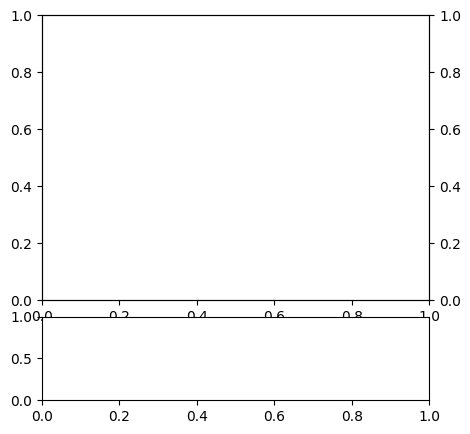

In [24]:
af_model.plot_traj()

In [25]:
af_model.save_pdb(f"{af_model.protocol}.pdb")
af_model.plot_pdb(show_mainchains=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [26]:
HTML(af_model.animate())

In [ ]:
af_model.get_seqs()

# hallucination (~1 minute)
For a given length, generate/hallucinate a protein sequence that AlphaFold thinks folds into a well structured protein (high plddt, low pae, many contacts).

In [ ]:
clear_mem()
af_model = mk_afdesign_model(protocol="hallucination")
af_model.prep_inputs(length=13, rm_aa="C")
add_cyclic_offset(af_model)
# add_rg_loss(af_model)

print("length",af_model._len)
print("weights",af_model.opt["weights"])

In [ ]:
# pre-design with gumbel initialization and softmax activation
af_model.restart()
af_model.set_seq(mode="gumbel")
af_model.set_opt("con", binary=True, cutoff=21.6875, num=af_model._len, seqsep=0)
af_model.set_weights(pae=1, plddt=1, con=0.5)
af_model.design_soft(50)

# three stage design
af_model.set_seq(seq=af_model.aux["seq"]["pseudo"])
af_model.design_3stage(50,50,10)

In [ ]:
af_model.save_pdb(f"{af_model.protocol}.pdb")
af_model.plot_pdb(show_mainchains=True)

In [ ]:
HTML(af_model.animate())

In [ ]:
af_model.get_seqs()